In [1]:
from attention_predict.stimulate import stimulate
from attention_predict.unet import UNet
import numpy as np
import matplotlib.pyplot as plt

In [10]:
depth = 5

prj_directory = '/store1/alicia/attention_predict'
ds_name = 'RID_AVE_RIV_AVD_AIN_eval'
exp = 'exp_2024102201'
ckpt = 201

mask_indices = [0, 1, 2, 3, 4]
stim_indices = [5, 6, 7]

device = 'cuda:3'
model_ckpt_path = f'/store1/alicia/attention_predict/{exp}/checkpoints/model_ckpt{ckpt}.pt'
in_channels = np.load(f'{prj_directory}/data/{ds_name}.npy').shape[1]
out_channels = in_channels
unet_dim = 1

max_length = 1600
window_size = 400
window_stride = 400

data_path = f'{prj_directory}/data/{ds_name}.npy'
dataset_path = f'{prj_directory}/data/{ds_name}_ds.npy'
datasets = np.load(dataset_path)

model = UNet(
        depth, in_channels, out_channels, unet_dim=unet_dim
).to(device)

In [13]:
response_traces = stimulate(
        data_path,
        dataset_path,
        model,
        model_ckpt_path,
        mask_indices,
        stim_indices,
        max_length,
        window_size,
        window_stride,
        device=device,
)

20it [00:00, 455.62it/s]


 All frames added to worm0: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm1: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm2: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm3: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm4: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]


### plot response traces

In [14]:
def plot_multiple_traces(worm_idx, mask_indices, response_traces, xrange, variables):

    masked_outcomes = {}
    
    mask_index = 0
    concatenated_prediction = np.concatenate(
        response_traces[worm_idx][mask_index]['prediction'],
        axis=2)
    concatenated_ground_truth = np.concatenate(
        response_traces[worm_idx][mask_index]['ground_truth'],
        axis=2)
    concatenated_inputs = np.concatenate(
        response_traces[worm_idx][mask_index]['inputs'],
        axis=2)
    
    prediction = concatenated_prediction.squeeze(0)
    ground_truth = concatenated_ground_truth.squeeze(0)
    inputs = concatenated_inputs.squeeze(0)
    
    masked_outcomes['prediction'] = prediction
    masked_outcomes['ground_truth'] = ground_truth
    masked_outcomes['inputs'] = inputs
    
    # summing MSE of reconstructing 4 segments (given window size = 4)
    masked_outcomes['mse'] = np.sum(response_traces[worm_idx][mask_index]['mse'])

    num_variables = len(variables)
    
    fig, axs = plt.subplots(num_variables, 1, figsize=(12, num_variables * 2), sharex=True)
    for i in range(num_variables):
        
        axs[i].plot(ground_truth[i][:xrange], label='ground truth', alpha=0.8)
        axs[i].plot(prediction[i][:xrange], label='prediction')
        axs[i].plot(inputs[i][:xrange], label='input signal')
        axs[i].set_title(
            f'{variables[i]} from {datasets[worm_idx]}')
        axs[i].grid(True)
        axs[i].legend()

    return masked_outcomes

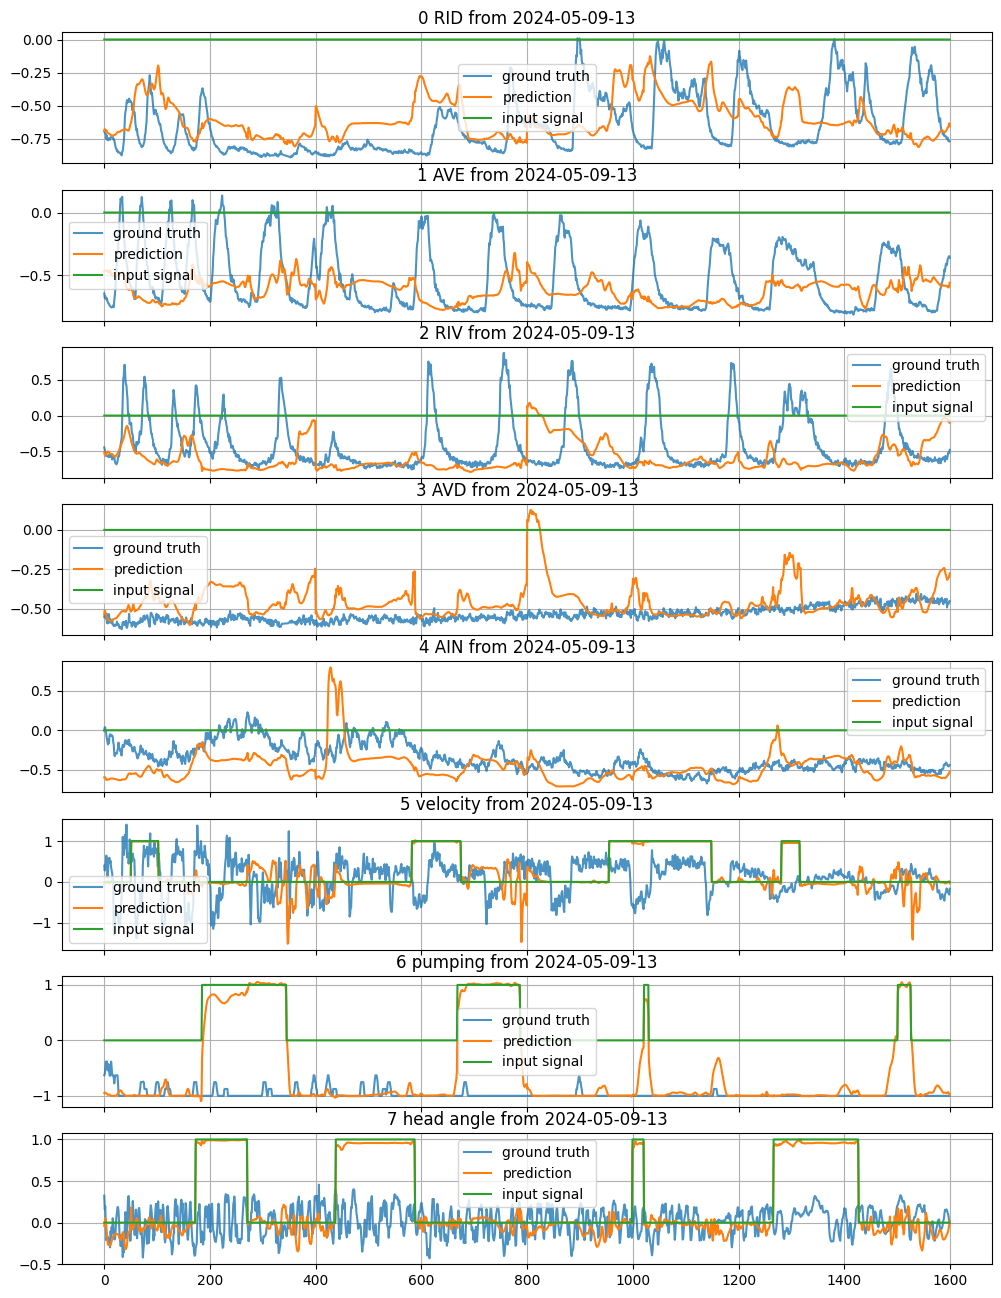

In [15]:
worm_idx = 4
variables = {0: '0 RID', 1: '1 AVE', 2: '2 RIV', 3: '3 AVD', 4: '4 AIN', 5: '5 velocity', 6: '6 pumping', 7: '7 head angle'}

masked_outcomes = plot_multiple_traces(
    worm_idx,
    mask_indices,
    response_traces,
    xrange=1600,
    variables=variables)